In [14]:
import numpy as np
import dill as pickle
import matplotlib
import corner
from matplotlib import pyplot as plt
from pkg_resources import resource_filename
from scipy.stats import gaussian_kde
from scipy import optimize
from astropy.io import fits
import os
import cue
from cue.line import predict
from cue.utils import (c, cont_lam, new_sorted_line_name, 
                       logQ, Qtotal,
                       get_loglinear_spectra, ionparam2norm, calcQ) # this includes some constants and functions for the fits and output plots

## Comparing abundance files themselves (Sep vs Dec)


In [15]:
dir = os.listdir('/home/carolinevr/ABUND_20250918_v2') 
path = os.path.join('/home/carolinevr/ABUND_20250918_v2', "cecilia_2593_25.abund.fits")
# Open fits file
hdu = fits.open(path)
mos = hdu[7].data
for i in range(len(mos['NAMES'])):
    print(mos["NAMES"][i],mos["I_CORR"][i], mos['I_UNC_CORR'][i])

[O II] 19.11331752373948 20.705526794659384
[O II] 19.375327697101575 20.92364271009454
HBeta 8.06672797903955 5.646526244718173
[O III] 19.17306573785026 12.904218706400203
HAlpha 22.73461273557195 12.266389012994601


In [16]:
dir = os.listdir('/home/carolinevr/ABUND_20251204') 
path = os.path.join('/home/carolinevr/ABUND_20251204', "cecilia_2593_25.abund.fits")
# Open fits file
hdu = fits.open(path)

mos = hdu[7].data
for i in range(len(mos['NAMES'])):
    print(mos["NAMES"][i],mos["I_CORR"][i], mos['I_UNC_CORR'][i])

[O II] 18.741610540529965 21.06764428744429
[O II] 19.707542111438404 22.123849280929367
HBeta 8.067120311808088 5.868164433750609
[O III] 6.738850582769925 4.77200759112637
[O III] 19.173962141950078 13.410090310361369
HAlpha 22.735718477042514 12.709085631274924


## Comparing luminosity files

In [17]:
# plt.figure(figsize=(10,4))
# plt.title("upper limit line")

# for line in range(len(sep_obs["line_name"])):
#     if fluxSN_obs["line_lum_up"][line] != 0:
#         plt.errorbar(sep_obs["line_name"][line], sep_obs["line_lum_up"][line], yerr=sep_obs["line_lum_unc"][line], marker = "s", capsize=10, alpha = 0.8, color = "blue")
#         plt.errorbar(dec_obs["line_name"][line], dec_obs["line_lum_up"][line], yerr=dec_obs["line_lum_unc"][line], marker = "d", color = "red")
#         plt.errorbar(fluxSN_obs["line_name"][line], fluxSN_obs["line_lum_up"][line], yerr=fluxSN_obs["line_lum_unc"][line], marker = "d", capsize=10, alpha = 0.5,color = "green")
        
# plt.xticks(rotation=90)
# plt.show()

In [27]:
galaxies = ["BX348"]#["BX523", "BX587", "BX628", "D40", "fBM40", "fBM47","fC23", "BX216", "BX274", "BX336", "BX341", "BX348", "BX350", "BX390", "BX418", "BX429", "BX461", "BX474", "D19", "C31"] 

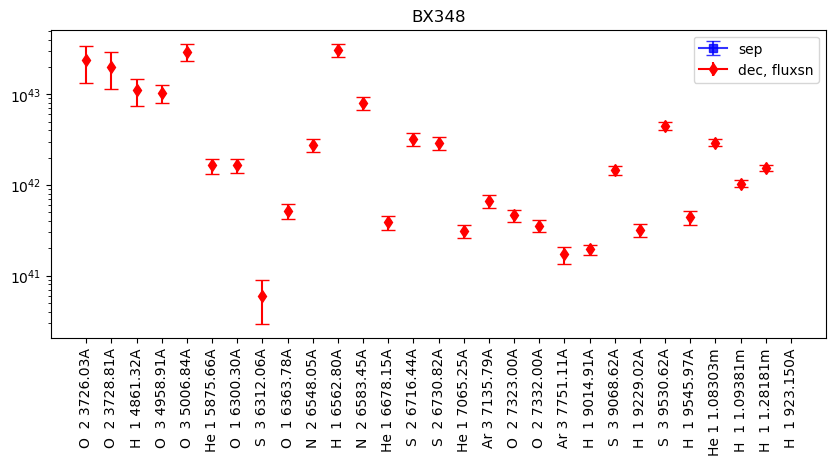

In [29]:
for galaxy in galaxies:
    # these are the obs used in the 56% runs
    with open("galaxy-observational-data/line_luminosities_dec_test/"+galaxy+"_fluxSN.pkl", 'rb') as f:
        fluxSN_obs = pickle.load(f) 

    with open("galaxy-observational-data/line_luminosities_dec/"+galaxy+".pkl", 'rb') as f:
        dec_obs = pickle.load(f)

    with open("galaxy-observational-data/line_luminosities_test/"+galaxy+"_fluxSN.pkl", 'rb') as f:
        nov_obs = pickle.load(f)

    with open("galaxy-observational-data/line_luminosities_sep_test/"+galaxy+".pkl", 'rb') as f:
        sep_obs = pickle.load(f)

    plt.figure(figsize=(10,4))
    plt.title(galaxy)
    for line in range(len(dec_obs["line_name"])):
        if (dec_obs['line_lum'][line] !=0): #(sep_obs['line_lum'][line] != 0): or (dec_obs['line_lum'][line] !=0):
            #plt.errorbar(sep_obs["line_name"][line], sep_obs["line_lum"][line], yerr=sep_obs["line_lum_unc"][line], marker = "s", capsize=5, alpha = 0.8, color = "blue")
            plt.errorbar(dec_obs["line_name"][line], dec_obs["line_lum"][line], yerr=dec_obs["line_lum_unc"][line], marker = "d", capsize=5,color = "red")
            #plt.errorbar(nov_obs["line_name"][line], nov_obs["line_lum"][line], yerr=nov_obs["line_lum_unc"][line], marker = "d", color = "purple")
        # elif (sep_obs['line_lum_up'][line] != 0) or (dec_obs['line_lum_up'][line] !=0):
        #     plt.errorbar(dec_obs["line_name"][line], dec_obs["line_lum_up"][line], yerr=dec_obs["line_lum_unc"][line],uplims=True,  marker = "o", capsize=5,color = "red")
        #     plt.errorbar(nov_obs["line_name"][line], nov_obs["line_lum_up"][line], yerr=nov_obs["line_lum_unc"][line], uplims=True,marker = "o", color = "purple")

    # plt.ylim(40,44)   
    plt.errorbar(sep_obs["line_name"][0], sep_obs["line_lum"][0], yerr=sep_obs["line_lum_unc"][0], marker = "s", capsize=5, alpha = 0.8, color = "blue", label="sep")
    plt.errorbar(dec_obs["line_name"][0], dec_obs["line_lum"][0], yerr=dec_obs["line_lum_unc"][0], marker = "d", color = "red", label="dec, fluxsn")
    #plt.errorbar(nov_obs["line_name"][0], nov_obs["line_lum"][0], yerr=nov_obs["line_lum_unc"][0], marker = "d", color = "purple", label="nov, fluxsn")
    plt.xticks(rotation=90)
    plt.yscale('log')
    plt.legend()
    plt.show()

In [20]:
for line in range(len(sep_obs["line_name"])):
    if fluxSN_obs["line_lum"][line] != 0:
        print("original", sep_obs["line_name"][line], sep_obs["line_lum"][line], sep_obs["line_lum_unc"][line], "signal-to-noise",sep_obs["line_lum"][line]/sep_obs["line_lum_unc"][line] )
        print("test    ", dec_obs["line_name"][line], dec_obs["line_lum"][line], dec_obs["line_lum_unc"][line], "signal-to-noise", dec_obs["line_lum"][line]/dec_obs["line_lum_unc"][line],)
        print("flux SN ", fluxSN_obs["line_name"][line], fluxSN_obs["line_lum"][line], fluxSN_obs["line_lum_unc"][line], "signal-to-noise", fluxSN_obs["line_lum"][line]/fluxSN_obs["line_lum_unc"][line])
        print("\n")

original O  2 3726.03A 1.7390171240207704e+42 2.9961751401485375e+41 signal-to-noise 5.804123733349438
test     O  2 3726.03A 1.5672436970660643e+42 2.6785738990384916e+41 signal-to-noise 5.851037739256126
flux SN  O  2 3726.03A 1.5672436970660643e+42 7.809547480660592e+40 signal-to-noise 20.06830358541459


original O  2 3728.81A 2.606606277615947e+42 4.4797005928985146e+41 signal-to-noise 5.818706459418499
test     O  2 3728.81A 2.3491357305681014e+42 4.011916507788871e+41 signal-to-noise 5.855395360315723
flux SN  O  2 3728.81A 2.3491357305681014e+42 1.1699584450652189e+41 signal-to-noise 20.07879630662566


original H  1 4340.46A 9.0980390213057e+41 9.605964793690713e+40 signal-to-noise 9.47123919013463
test     H  1 4340.46A 9.0980390213057e+41 9.955568035132975e+40 signal-to-noise 9.138643811381657
flux SN  H  1 4340.46A 9.0980390213057e+41 5.27417822197087e+40 signal-to-noise 17.25015469406326


original O  3 4363.21A 6.902457603354238e+40 2.4126433792546006e+40 signal-to-noise 

# comparing to my mosfire line lists

In [21]:
from astropy.io import fits
bagpipes_lineDir = "/home/carolinevr/CECILIA-MOS/mos-galaxies-nyx/scratch-wsl-ver/"
date = "09162025"
bagpipes_mcmc_scor = fits.open(bagpipes_lineDir+"cecilia_linelist_mos_mask_bagpipes_MCMC_scor_"+date+".fits") 
bagpipes_mcmc_scor_fluxes = bagpipes_mcmc_scor[1].data
bagpipes_mcmc_scor.close()
bagpipes_uncor = fits.open(bagpipes_lineDir+"cecilia_linelist_mos_mask_bagpipes_"+date+".fits") 
bagpipes_uncor_mos_fluxes = bagpipes_uncor[1].data
bagpipes_uncor.close()

In [22]:
new_bagpipes_uncor = fits.open("/home/carolinevr/CECILIA-MOS/mos-galaxies-nyx/bagpipes-noahspaper/cecilia_linelist_mos_mask_bagpipes_11262025.fits") 
new_bagpipes_uncor_mos_fluxes = new_bagpipes_uncor[1].data
new_bagpipes_uncor.close()

In [23]:
bx587_ind = (new_bagpipes_uncor_mos_fluxes["OBJNAME"]==galaxy)
print(galaxy, "uncor")
print("o2",new_bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][1],new_bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][2])
print("5007",new_bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][1],new_bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][2])
print("4959",new_bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][1],new_bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][2])
print("Hb",new_bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][1],new_bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][2])
print("Ha",bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][1],new_bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][2])

C31 uncor
o2 0.5479183 0.030975796 sn 19.554064
5007 4.304679 0.08744448 sn 50.346043
4959 1.4895083 0.030257603 sn 50.346043
Hb 0.97228146 0.114075445 sn 8.352713
Ha 0.0 0.0 sn nan


/tmp/ipykernel_10459/2435056690.py:7: RuntimeWarning: invalid value encountered in scalar divide
  print("Ha",bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][1],new_bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][2])


In [24]:
bx587_ind = (bagpipes_mcmc_scor_fluxes["OBJNAME"]==galaxy)
print(galaxy, "mcmc corr")
print("o2", bagpipes_mcmc_scor_fluxes["[O II]3726"][bx587_ind][0][1], bagpipes_mcmc_scor_fluxes["[O II]3726"][bx587_ind][0][2],  "sn",bagpipes_mcmc_scor_fluxes["[O II]3726"][bx587_ind][0][1]/bagpipes_mcmc_scor_fluxes["[O II]3726"][bx587_ind][0][2])
print("5007", bagpipes_mcmc_scor_fluxes["[O III]5007"][bx587_ind][0][1], bagpipes_mcmc_scor_fluxes["[O III]5007"][bx587_ind][0][2], "sn", bagpipes_mcmc_scor_fluxes["[O III]5007"][bx587_ind][0][1]/bagpipes_mcmc_scor_fluxes["[O III]5007"][bx587_ind][0][2])
print("4959", bagpipes_mcmc_scor_fluxes["[O III]4959"][bx587_ind][0][1], bagpipes_mcmc_scor_fluxes["[O III]4959"][bx587_ind][0][2],"sn",bagpipes_mcmc_scor_fluxes["[O III]4959"][bx587_ind][0][1]/bagpipes_mcmc_scor_fluxes["[O III]4959"][bx587_ind][0][2])
print("Hb", bagpipes_mcmc_scor_fluxes["Hbeta"][bx587_ind][0][1], bagpipes_mcmc_scor_fluxes["Hbeta"][bx587_ind][0][2],"sn",bagpipes_mcmc_scor_fluxes["Hbeta"][bx587_ind][0][1]/bagpipes_mcmc_scor_fluxes["Hbeta"][bx587_ind][0][2])
print("Ha",bagpipes_mcmc_scor_fluxes["Halpha"][bx587_ind][0][1], bagpipes_mcmc_scor_fluxes["Halpha"][bx587_ind][0][2],"sn", bagpipes_mcmc_scor_fluxes["Halpha"][bx587_ind][0][1]/bagpipes_mcmc_scor_fluxes["Halpha"][bx587_ind][0][2])

bx587_ind = (bagpipes_uncor_mos_fluxes["OBJNAME"]==galaxy)
print(galaxy, "uncor")
print("o2", bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][1], bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][2])
print("5007", bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][1], bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][2])
print("4959", bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][1], bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][2])
print("Hb", bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][1], bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][2])
print("Ha",bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][1], bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][2])

print(galaxy, "flux_SN luminosity file")
print("o2", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='O  2 3728.81A')], *fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='O  2 3728.81A')], "signal-to-noise", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='O  2 3728.81A')]/fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='O  2 3728.81A')])
print("5007", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='O  3 5006.84A')], *fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='O  3 5006.84A')], "signal-to-noise", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='O  3 5006.84A')]/fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='O  3 5006.84A')])
print("4959", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='O  3 4958.91A')], *fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='O  3 4958.91A')], "signal-to-noise", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='O  3 4958.91A')]/fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='O  3 4958.91A')])
print("Hb", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='H  1 4861.32A')], *fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='H  1 4861.32A')], "signal-to-noise", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='H  1 4861.32A')]/fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='H  1 4861.32A')])
print("Ha", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='H  1 6562.80A')], *fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='H  1 6562.80A')], "signal-to-noise", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='H  1 6562.80A')]/fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='H  1 6562.80A')])

C31 mcmc corr
o2 0.8556174 0.0437565 sn 19.554064
5007 8.396684 0.5151534 sn 16.299385
4959 2.905427 0.17825377 sn 16.299385
Hb 1.8968449 0.2523788 sn 7.515865
Ha 0.0 0.0 sn nan
C31 uncor
o2 0.8556174 0.0437565 sn 19.554064
5007 4.2889876 0.08519016 sn 50.346043
4959 1.4840788 0.029477565 sn 50.346043
Hb 0.9688996 0.11599819 sn 8.352713
Ha 0.0 0.0 sn nan
C31 flux_SN luminosity file
o2 2.3491357305681014e+42 1.1699584450652189e+41 signal-to-noise 20.07879630662566
5007 9.039989891641074e+42 4.112955334126737e+40 signal-to-noise 219.7930479972121
4959 3.141143495730029e+42 1.429136874142567e+40 signal-to-noise 219.79304799721208
Hb 1.75054016590005e+42 3.4745979942792943e+40 signal-to-noise 50.38108491348362
Ha 5.394743746561804e+42 3.117067169632369e+40 signal-to-noise 173.0711419734361


/tmp/ipykernel_10459/1900319474.py:7: RuntimeWarning: invalid value encountered in scalar divide
  print("Ha",bagpipes_mcmc_scor_fluxes["Halpha"][bx587_ind][0][1], bagpipes_mcmc_scor_fluxes["Halpha"][bx587_ind][0][2],"sn", bagpipes_mcmc_scor_fluxes["Halpha"][bx587_ind][0][1]/bagpipes_mcmc_scor_fluxes["Halpha"][bx587_ind][0][2])
/tmp/ipykernel_10459/1900319474.py:15: RuntimeWarning: invalid value encountered in scalar divide
  print("Ha",bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][1], bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][2])
